In [83]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve, make_scorer, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from src.eda import load_data

In [13]:
df = load_data()

# drop non-informative columns
df = df.drop(columns=["state"])
df['area_code'] = df['area_code'].cat.codes
df['international_plan'] = df['international_plan'].cat.codes
df['voice_mail_plan'] = df['voice_mail_plan'].cat.codes
df

,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,128,1,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,1,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,1,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,0,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,1,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,79,1,0,0,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,False
2662,192,1,0,1,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
2663,68,1,0,0,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
2664,28,2,0,0,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False


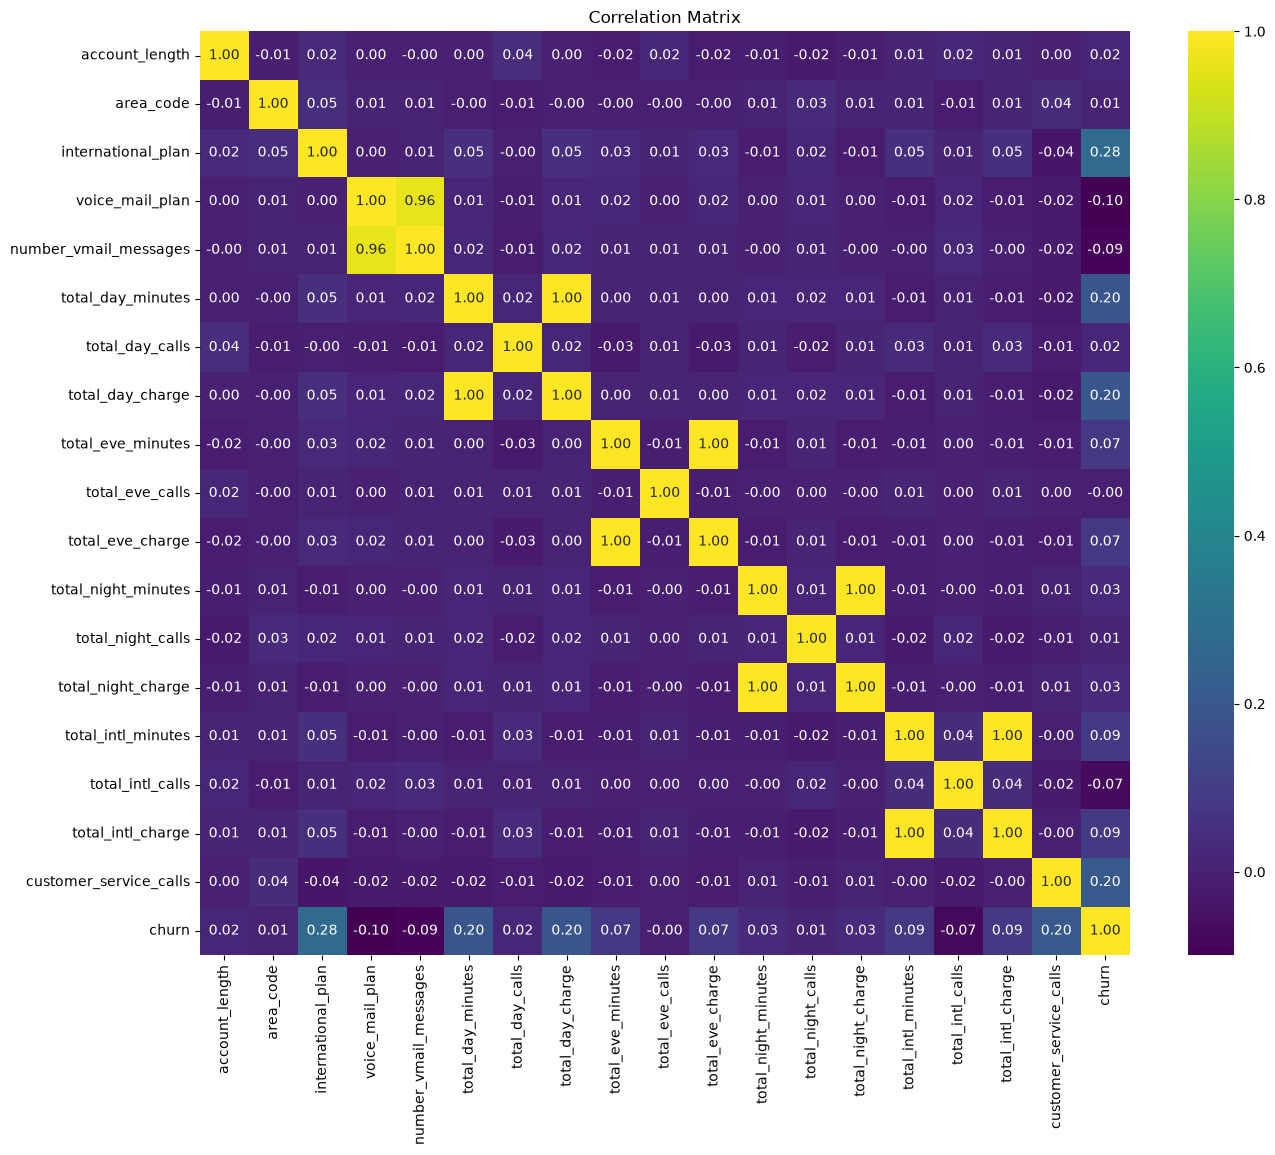

In [23]:
_, ax = plt.subplots(figsize=(15, 12))

sns.heatmap(
    data=df.corr(),
    annot=True,
    cmap="viridis",
    fmt=".2f",
    ax=ax,
)

ax.set_title("Correlation Matrix")
plt.show()

In [84]:
# loading data
X = df.drop(columns=['churn'])
y = df['churn']

print(f"X.shape = {X.shape}")
print(f"y.shape = {y.shape} -> binary\n")

# train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Traning set shape = {X_train.shape}")
print(f"Validation set shape = {X_val.shape}")
print("--" * 30)

# standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# traning baseline models
log_reg = LogisticRegression(random_state=42)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
knn = KNeighborsClassifier()
svm = SVC(random_state=42)
naive_bayes = GaussianNB()
rf = RandomForestClassifier(random_state=42)

models = [log_reg, dt, knn, svm, naive_bayes, rf]
model_names = ['log_reg', 'dt', 'knn', 'svm', 'naive_bayes', 'rf']

for model, name in zip(models, model_names):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    print(f"{name} train f1-score = {f1_score(y_val, y_pred, average='macro')}")
    print(f"{name} val f1-score = {f1_score(y_val, y_pred, average='macro')}\n")

X.shape = (2666, 18)
y.shape = (2666,) -> binary

Traning set shape = (2132, 18)
Validation set shape = (534, 18)
------------------------------------------------------------
log_reg train f1-score = 0.6209653317393903
log_reg val f1-score = 0.6209653317393903

dt train f1-score = 0.7925407925407926
dt val f1-score = 0.7925407925407926

knn train f1-score = 0.6933547968030727
knn val f1-score = 0.6933547968030727

svm train f1-score = 0.7552374019250991
svm val f1-score = 0.7552374019250991

naive_bayes train f1-score = 0.689760348583878
naive_bayes val f1-score = 0.689760348583878

rf train f1-score = 0.8840577379277069
rf val f1-score = 0.8840577379277069



In [85]:
for model, model_name in zip(models, model_names):
    pipe = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('clf', model)
    ])
    f1_cv_scores = cross_val_score(
        estimator=pipe,
        X=X,
        y=y,
        cv=5,
        scoring=make_scorer(f1_score, greater_is_better=True),
        n_jobs=-1
	)
    auc_cv_scores = cross_val_score(
        estimator=pipe,
        X=X,
        y=y,
        cv=5,
        scoring=make_scorer(roc_auc_score, greater_is_better=True),
        n_jobs=-1
	)
    print(f"Model: {model_name}, CV F1-score: {f1_cv_scores.mean()} ± {f1_cv_scores.std()}")
    print(f"Model: {model_name}, CV AUC: {auc_cv_scores.mean()} ± {auc_cv_scores.std()}\n")

Model: log_reg, CV F1-score: 0.318822216946113 ± 0.024449302977923696
Model: log_reg, CV AUC: 0.5965580034001087 ± 0.010214102485353904

Model: dt, CV F1-score: 0.7423050693444128 ± 0.021498565814864017
Model: dt, CV AUC: 0.8300097709308234 ± 0.01682210299058864

Model: knn, CV F1-score: 0.4766071530136865 ± 0.059671666471993096
Model: knn, CV AUC: 0.6638648632069685 ± 0.027593266731616065

Model: svm, CV F1-score: 0.6024831104014605 ± 0.04011345620181795
Model: svm, CV AUC: 0.727341386683492 ± 0.023082829575880936

Model: naive_bayes, CV F1-score: 0.5244932686532873 ± 0.0509040258963045
Model: naive_bayes, CV AUC: 0.7211543281280124 ± 0.027236492845077717

Model: rf, CV F1-score: 0.816177506883127 ± 0.0471998712196758
Model: rf, CV AUC: 0.8570430446746237 ± 0.031131247820569877



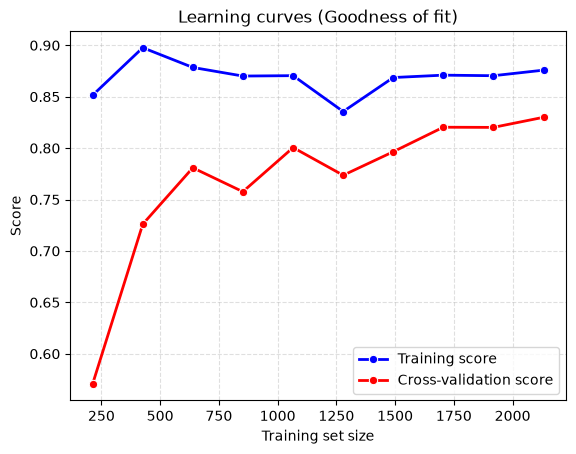

In [80]:
# plot learning curves
train_sizes, train_scores, test_scores = learning_curve(
    estimator=dt,
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring=make_scorer(roc_auc_score, greater_is_better=True),
    n_jobs=-1,
)

sns.lineplot(
    x=train_sizes,
    y=train_scores.mean(axis=1),
    label="Training score",
    color="b",
    lw=2,
    marker="o",
)
sns.lineplot(
    x=train_sizes,
    y=test_scores.mean(axis=1),
    label="Cross-validation score",
    color="r",
    lw=2,
    marker="o",
)

plt.title("Learning curves (Goodness of fit)")
plt.xlabel("Training set size")
plt.ylabel("Score")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.4)

In [96]:
dt.fit(X_train_scaled, y_train)

y_pred = dt.predict(X_val_scaled)

acc = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred)
dt_cm = confusion_matrix(y_val, y_pred)

print(f"Accuracy: {acc:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")

Accuracy: 0.91
Precision: 0.79
Recall: 0.53
F1-score: 0.64
ROC-AUC: 0.75


In [97]:
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_val_scaled)

acc = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred)
rf_cm = confusion_matrix(y_val, y_pred)

print(f"Accuracy: {acc:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")

Accuracy: 0.95
Precision: 0.98
Recall: 0.67
F1-score: 0.80
ROC-AUC: 0.83


<Axes: ylabel='None'>

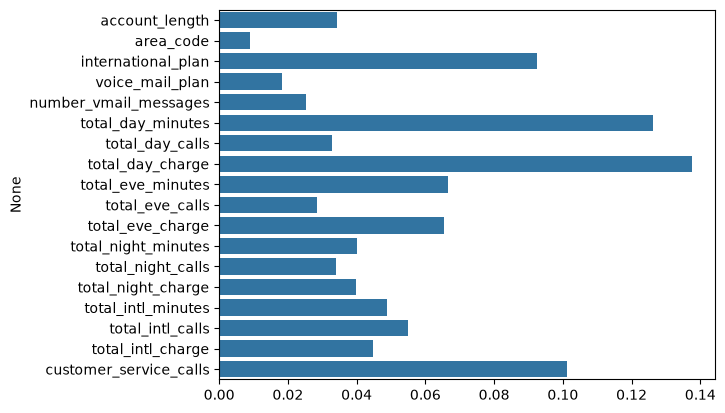

In [98]:
sns.barplot(
    x=rf.feature_importances_,
    y=X.columns,
)

In [136]:
from xgboost import XGBClassifier

bst = XGBClassifier(n_estimators=100, objective="binary:logistic")
bst.fit(X_train_scaled, y_train)

y_pred = bst.predict(X_val_scaled)

acc = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred)
rf_cm = confusion_matrix(y_val, y_pred)
bst_cm = confusion_matrix(y_val, y_pred)

print(f"Accuracy: {acc:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")

Accuracy: 0.95
Precision: 0.95
Recall: 0.71
F1-score: 0.81
ROC-AUC: 0.85


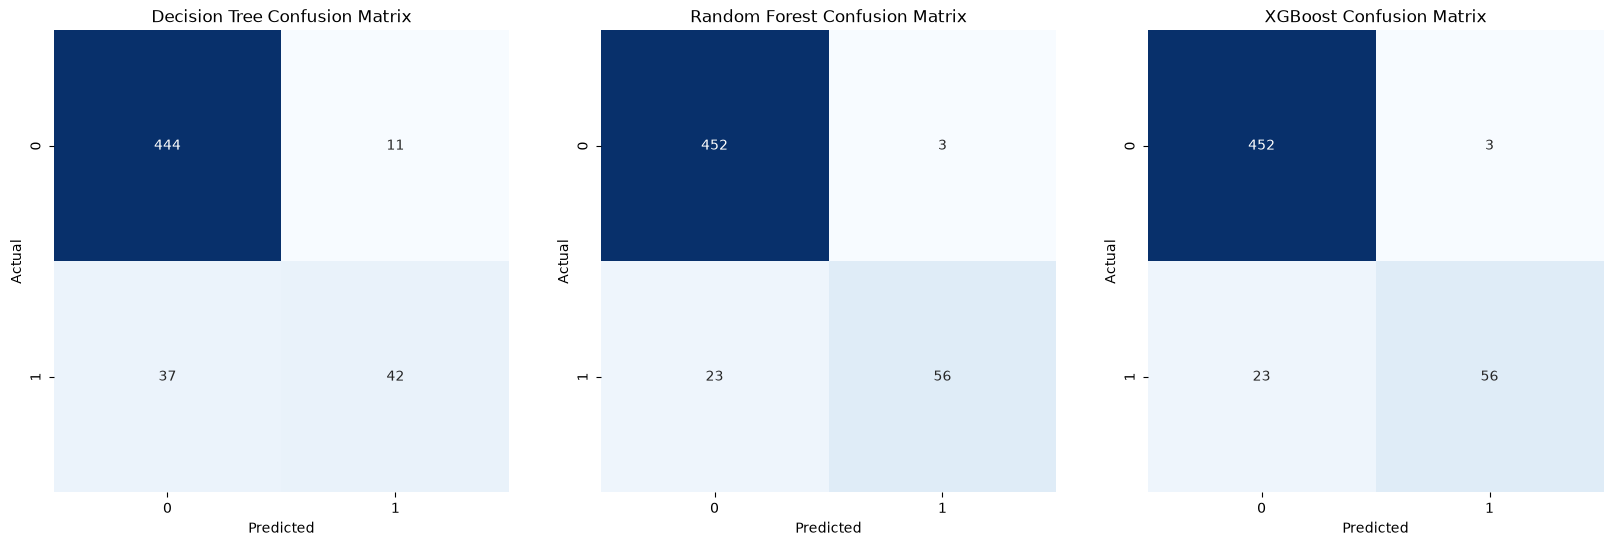

In [149]:
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
sns.heatmap(
    data=dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax1,
)
sns.heatmap(
    data=rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax2,
)
sns.heatmap(
    data=bst_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax3,
)

ax1.set(
    title="Decision Tree Confusion Matrix",
    xlabel="Predicted",
    ylabel="Actual",
)
ax2.set(
    title="Random Forest Confusion Matrix",
    xlabel="Predicted",
    ylabel="Actual",
)
ax3.set(
    title="XGBoost Confusion Matrix",
    xlabel="Predicted",
    ylabel="Actual",
)

plt.show()